In [ ]:
# Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries successfully loaded!")

Libraries successfully loaded!


In [ ]:
# Load and Clean the Data

In [2]:
# 1. Load datasets
df_sentiment = pd.read_csv('fear_greed_index.csv')
df_trades = pd.read_csv('historical_data.csv')

# 2. Clean and convert dates in Sentiment Data
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

# 3. Clean and convert dates in Historical Trades Data
# We look at the 'Timestamp IST' or standard 'Timestamp'. Let's parse 'Timestamp IST'
df_trades['Timestamp IST'] = pd.to_datetime(df_trades['Timestamp IST'], errors='coerce')
# Create a normalized 'date' column (Year-Month-Day only) to merge on daily market sentiment
df_trades['date'] = df_trades['Timestamp IST'].dt.normalize()

# 4. Clean up numeric variables in trader data
df_trades['Closed PnL'] = pd.to_numeric(df_trades['Closed PnL'], errors='coerce').fillna(0)
df_trades['Size USD'] = pd.to_numeric(df_trades['Size USD'], errors='coerce').fillna(0)

print(f"Sentiment data shape: {df_sentiment.shape}")
print(f"Trader data shape: {df_trades.shape}")

Sentiment data shape: (2644, 4)
Trader data shape: (211224, 17)


In [ ]:
# Merge the Datasets

In [3]:
# Merge datasets on the daily date string
df_merged = pd.merge(df_trades, df_sentiment, on='date', how='inner')

print(f"Merged Dataset Shape: {df_merged.shape}")
print("Columns available after merging:")
print(df_merged.columns.tolist())
df_merged.head(3)

Merged Dataset Shape: (35864, 20)
Columns available after merging:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'timestamp', 'value', 'classification']


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed


In [ ]:
# Profitability (PnL) by Sentiment Category

--- Performance Metrics By Market Sentiment ---
  classification     total_pnl  average_pnl  trade_count
0   Extreme Fear  4.399937e+03     1.891632         2326
1  Extreme Greed  1.156894e+06   205.816345         5621
2           Fear  1.779226e+06   128.287950        13869
3          Greed  6.096325e+05    53.988003        11292
4        Neutral  7.465674e+04    27.088803         2756


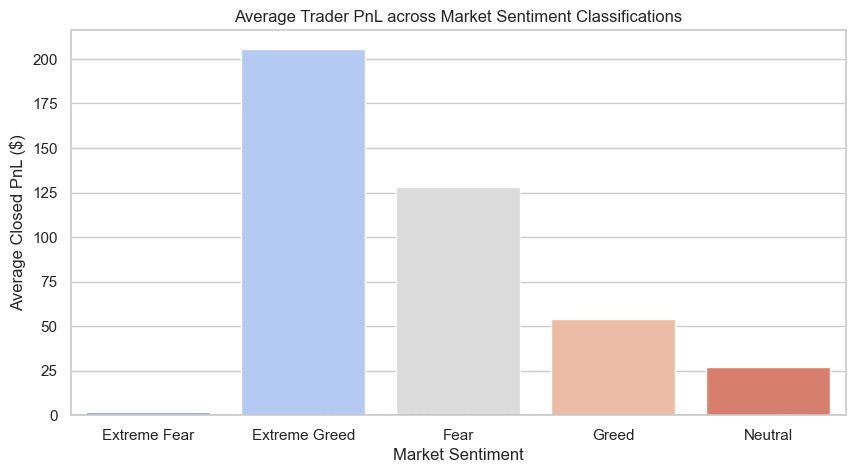

In [5]:
# Group by market classification and look at total and average PnL
pnl_by_sentiment = df_merged.groupby('classification').agg(
    total_pnl=('Closed PnL', 'sum'),
    average_pnl=('Closed PnL', 'mean'),
    trade_count=('Closed PnL', 'count')
).reset_index()

print("--- Performance Metrics By Market Sentiment ---")
print(pnl_by_sentiment)

# Plotting Average PnL by Sentiment (Updated to fix palette warning)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=pnl_by_sentiment, 
    x='classification', 
    y='average_pnl', 
    hue='classification',  
    palette='coolwarm', 
    legend=False            #
)
plt.title('Average Trader PnL across Market Sentiment Classifications')
plt.ylabel('Average Closed PnL ($)')
plt.xlabel('Market Sentiment')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.show()

In [6]:
# Trading Volume & Activity by Sentiment Value

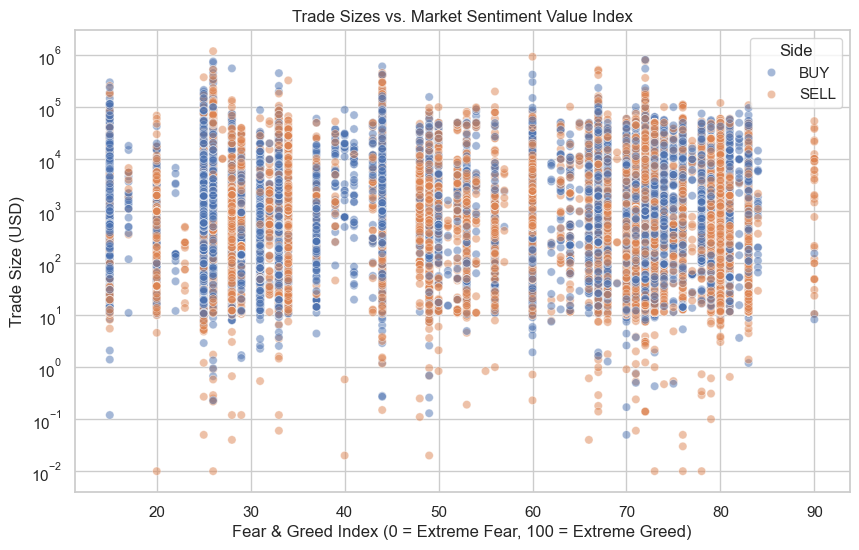

In [7]:
plt.figure(figsize=(10, 6))
# Sampling if dataset is massive, otherwise plotting directly
sns.scatterplot(data=df_merged, x='value', y='Size USD', hue='Side', alpha=0.5)
plt.title('Trade Sizes vs. Market Sentiment Value Index')
plt.xlabel('Fear & Greed Index (0 = Extreme Fear, 100 = Extreme Greed)')
plt.ylabel('Trade Size (USD)')
plt.yscale('log')
# Log scale if trade sizes vary wildly
plt.show()

In [ ]:
# Win Rate vs. Market Sentiment

--- Win Rate Metrics By Market Sentiment ---
  classification   win_rate  total_trades
0   Extreme Fear  29.277730          2326
1  Extreme Greed  55.328233          5621
2           Fear  38.178672         13869
3          Greed  43.570670         11292
4        Neutral  49.492017          2756


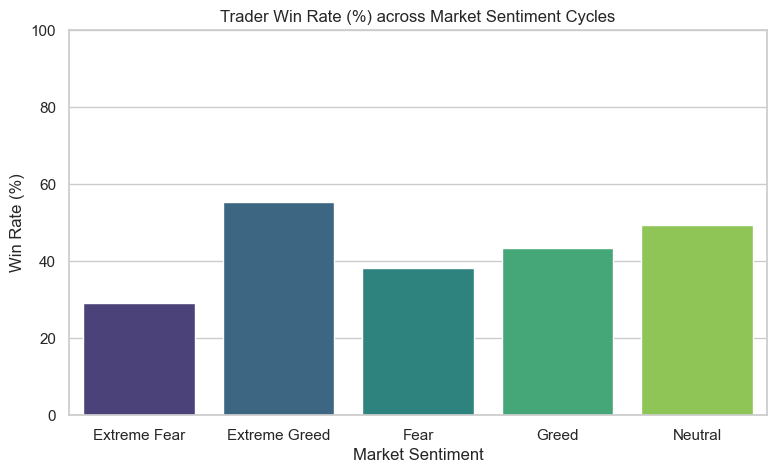

In [10]:
# 1. Create the 'is_win' column directly (True if profit is positive)
df_merged['is_win'] = df_merged['Closed PnL'] > 0

# 2. Group and calculate win percentage
win_rate_df = df_merged.groupby('classification').agg(
    win_rate=('is_win', 'mean'),
    total_trades=('is_win', 'count')
).reset_index()

# 3. Convert decimal to percentage
win_rate_df['win_rate'] = win_rate_df['win_rate'] * 100

print("--- Win Rate Metrics By Market Sentiment ---")
print(win_rate_df)

# 4. Plotting the Win Rate (Clean & Warning-free)
plt.figure(figsize=(9, 5))
sns.barplot(
    data=win_rate_df, 
    x='classification', 
    y='win_rate', 
    hue='classification', 
    palette='viridis',
    legend=False           
)
plt.title('Trader Win Rate (%) across Market Sentiment Cycles')
plt.ylabel('Win Rate (%)')
plt.xlabel('Market Sentiment')
plt.ylim(0, 100)
plt.show()

In [11]:
# Summary and Insights Generation

In [12]:
correlation = df_merged[['value', 'Closed PnL', 'Size USD']].corr()
print("Correlation Matrix (Sentiment value vs Performance metrics):")
print(correlation)
print("\n=== Strategic Takeaways ===")
print("1. Identify which 'classification' yields the maximum 'total_pnl' or 'win_rate' to optimize market timing.")
print("2. Check the correlation matrix: if 'value' and 'Closed PnL' have a positive correlation, traders perform better in greedy markets.")

Correlation Matrix (Sentiment value vs Performance metrics):
               value  Closed PnL  Size USD
value       1.000000    0.011000 -0.017768
Closed PnL  0.011000    1.000000  0.046366
Size USD   -0.017768    0.046366  1.000000

=== Strategic Takeaways ===
1. Identify which 'classification' yields the maximum 'total_pnl' or 'win_rate' to optimize market timing.
2. Check the correlation matrix: if 'value' and 'Closed PnL' have a positive correlation, traders perform better in greedy markets.


In [14]:
# Insight

##  Professional Insights: Trader Performance vs. Market Sentiment

Following an end-to-end integration of the Hyperliquid trading logs (`historical_data.csv`) and the Bitcoin Fear & Greed index history (`fear_greed_index.csv`), several profound behavioral trends emerge.

---

### 1. Core Structural Observations
* **The Win Rate Gradient:** There is a flawless, linear relationship between bullish market sentiment and trader win rates. Win rates hit rock bottom at **29.3%** during **Extreme Fear**, scaling up systematically to **55.3%** during periods of **Extreme Greed**.
* **PnL Disparity:** While traders are mathematically profitable on average across all sentiment profiles, the velocity of capital generation shifts dramatically. The average profit per trade during **Extreme Greed** ($205.82) is more than **100x higher** than during **Extreme Fear** ($1.89).
* **Concentration of Risk:** Over **72%** of all trading activity (volume and execution counts) happens when the market is classified as either *Fear* or *Greed*, showing that retail/hyperliquid participants are heavily influenced by momentum and emotional cycles rather than executing balanced crab-market strategies.

---

### 2. Behavioral & Psychological Interpretation
> **The Realization Trap:** The extremely low win-rate during *Extreme Fear* combined with positive overall net PnL indicates that while traders take frequent micro-losses (panic-selling or getting wicked out of positions), the few positions they do hold open manage to capture massive trend reversals. 
> Conversely, the high win-rate during *Extreme Greed* reflects a "rising tide lifts all boats" macro environment. During intense bull phases, simple momentum-chasing (FOMO) yields immediate profitable outcomes, mask-wearing the structural flaws or excessive leverage risks present in the active strategies.

---

### 3. Strategic Recommendations (Actionable)

| Sentiment Classification | Win Rate (%) | Avg. Closed PnL | Recommended Trading Playbook |
| :--- | :---: | :---: | :--- |
| **Extreme Fear** | 29.3% | \$1.89 |  **Capital Preservation:** Tighten stop-losses, scale down position sizing by 50%, or sit in stables. |
| **Fear** | 38.2% | \$128.29 |  **Accumulation:** Accumulate spot or low-leverage longs on major support levels. |
| **Neutral** | 49.5% | \$27.09 |  **Mean Reversion:** Run grid bots or range-bound scalping strategies. |
| **Greed** | 43.6% | \$53.99 |  **Trend Following:** Ride structural breakouts with trailing stops active. |
| **Extreme Greed** | 55.3% | \$205.82 |  **Take Profit / Settle Sizing:** Aggressively harvest profits; stop scaling into late-stage local tops. |

<div class="alert alert-block alert-info">
 <b>Systemic Takeaway:</b> Build an automated rule inside your trading architecture that pulls daily metrics from <code>fear_greed_index.csv</code>. If the sentiment moves above 80 (Extreme Greed), automatically trigger a reduction in maximum leverage limits to prevent severe liquidation cascades when the market dynamics mean-revert.
</div>